# 04 Dimensionality Reduction

#### \#\#\# *Characterising neighbourhoods* \#\#\#

This notebook is for dimensionality reduction.

We apply Principal Component Analysis (PCA) to the 45-dimensional standardised dataset to reduce dimensionality while retaining the majority of variance in the data. PCA creates new orthogonal variables (principal components) that are linear combinations of the original variables, ordered by the amount of variance they explain. Cumulative explained variance indicates that the first 4-7 principal components explained between 75\% and 90\% of the total variance, with the "elbow point" in the scree plot also occurring somewhere between the fourth and seventh component. Ultimately, five principal components were selected for the clustering analysis, as these explained just over 80\% of the cumulative variance, and we wanted to minimise the number of features to avoid the curse of dimensionality. 

PCA assumes linearity and is less good at capturing non-linear structures in the data; it is optimised to explain variance rather than to separate clusters. t-Distributed Stochastic Neighbour Embedding (t-SNE) might be better at revealing hidden clusters in the data. However, our demographic features often correlate, and PCA is useful for reducing that redundancy by creating uncorrelated components. In addition, the new axes that the principal components from PCA represent are easier to interpret than for example two new dimensions visualised with t-SNE, and it is easier to use principal components as variables for further analyses with different clustering methods.

*Author: loua*

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

np.random.seed(42)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option("display.max_colwidth", None)

In [2]:
ROOT = '../../'
PATH = ROOT + 'processed-data/characterising-neighbourhoods/'
STANDARDISED = PATH + '03_standardised.csv'
NOT_STANDARDISED = PATH + '02_afterEDA.csv'
PLOT_PATH = ROOT + 'data-wrangling/characterising-neighbourhoods/plots/'
OUTPUT_PATH_PNG = PLOT_PATH + 'png/'
OUTPUT_PATH_PGF = PLOT_PATH + 'pgf/'
OUTPUT_PATH_PDF = PLOT_PATH + 'pdf/'
OUTPUT_PATH = PATH + '04_pca.csv'

## Load data

In [3]:
df = pd.read_csv(STANDARDISED)
id_cols = ['PollingAreaID','PollingArea']
polling_areas = df[id_cols]
df_standardised = df.drop(columns=id_cols)
df_num = pd.read_csv(NOT_STANDARDISED).drop(columns=id_cols)
df.head()

,PollingAreaID,PollingArea,Sex_Female,Age_70- years,Age_0-17 years,Age_18-29 years,Age_30-69 years,Education_18-29 years_Long higher education,Education_18-29 years_Primary and lower secondary,Education_18-29 years_Vocational training,Education_30-70+ years_Long higher education,Education_30-70+ years_Primary and lower secondary,Education_30-70+ years_Vocational training,Income_Gross income top20pct,Income_Median household income,Socioeconomy_Self-employed,Socioeconomy_Top executives,Socioeconomy_Unemployed,Benefit type_Foertidspension,Benefit type_Kontanthjaelp,Benefit type_Modtager ikke ydelser,Housing type_People_Apartment buildings,Housing type_People_Detached house,Housing type_People_Terraced house,Housing tenure_People_Almen,Housing tenure_People_Andel,Housing tenure_People_Ejer,Housing tenure_People_Private rental,Year built_People_1960-2009,Year built_People_2010-9999,Year built_People_Before 1960,Car_Households with no car,Crime_Number of arrests,Immigrants_Other Europe,Immigrants_Western,Immigrants_Eastern Europe,Immigrants_Global South,Citizenship_Denmark,Citizenship_Other Europe,Citizenship_Western,Citizenship_Eastern Europe,Citizenship_Global South,Voter turnout
0,101001,"Østerbro, Østerbro",1.356335,0.007086,-0.404719,0.191708,0.062697,0.787257,-0.653443,-0.883139,0.838466,-1.038023,-0.898102,0.274336,0.159740,0.257086,0.416885,-1.011849,-0.843638,-0.738697,0.770517,0.886549,-0.669399,-0.691902,-0.449305,0.603768,-0.349396,0.568382,-0.443239,-0.498864,0.585355,0.339766,-0.698390,0.480677,1.479625,-0.948658,-1.375947,0.394659,-0.183502,0.846741,-0.740767,-0.731884,0.555239
1,101002,"Nord, Østerbro",1.672071,1.368694,-0.327499,-0.507790,-0.226487,-0.119959,-0.576554,-0.475453,0.749094,-0.399056,-0.348768,1.902492,-0.083391,1.118116,0.820992,-0.812992,-0.563750,-0.365954,-0.272560,-0.052262,0.183743,-0.226229,-0.548923,0.268477,0.364844,-0.220472,-0.328870,-0.398500,0.450972,-0.511237,-0.488082,1.953802,0.319941,-0.512968,-0.356938,0.501854,0.880540,-0.049402,-0.719054,-0.384547,0.423417
2,101003,"Syd, Østerbro",0.601267,-0.221721,0.431829,-0.414657,0.637756,0.258455,-0.642175,-1.203677,1.467915,-1.214478,-1.114106,0.833831,0.737777,0.913018,0.785683,-0.649722,-1.212836,-1.153182,1.215936,0.742888,-0.628461,-0.849836,-1.078598,1.384722,-0.381137,0.061959,-1.001797,-0.547228,0.982168,0.032852,-0.694368,0.727264,1.623194,-1.838701,-1.309599,0.729572,-0.212591,0.414959,-1.034950,-0.788376,1.256016
3,101005,"Vest, Østerbro",0.583423,0.561593,-0.717309,0.277082,-0.430409,0.263095,-0.832514,-0.563610,-0.125675,-0.093151,0.094952,-0.492205,-0.428371,-0.841306,-0.520303,-0.447623,-0.185581,-0.517075,-0.215500,0.460124,-0.671218,-0.189050,-0.401879,0.978312,-0.536908,-0.376160,0.392619,-0.457028,0.009478,0.472441,-0.292736,1.559406,0.246917,0.641578,-0.565626,-0.181989,1.483658,0.525503,-0.090360,-0.079864,-0.361646
4,101006,"Nordvest, Østerbro",0.477878,0.344750,-0.356093,0.179983,-0.383826,0.428088,-0.005004,0.007817,0.036599,-0.322415,0.062419,-0.261586,-0.303752,0.056948,-0.038763,-0.324913,0.130928,-0.309867,-0.340793,0.301235,-0.644915,0.850861,0.019346,0.207417,-0.227061,-0.081694,0.362382,-0.411435,0.002643,0.150110,-0.640056,1.252652,-0.081522,0.423183,-0.120744,0.393187,0.921160,-0.250072,-0.222157,-0.325612,0.125202


## t-SNE

This time on standardised data.

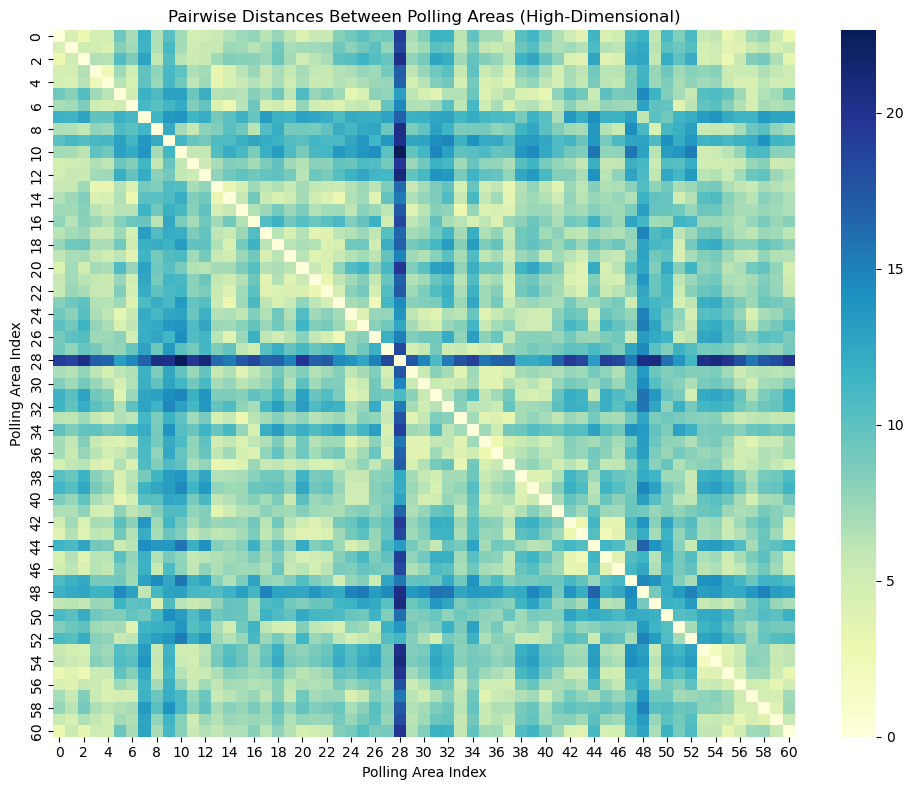

In [4]:
colors = [
    "#C03B26", # Red
    "#179E86", # Dark Green
    "#44546A", # Gray
]
# Calculate pairwise distances
df_dist = df_standardised.copy()
pairwise_dist = pairwise_distances(df_dist, metric="euclidean")

plt.figure(figsize=(10, 8))
sns.heatmap(pairwise_dist, cmap="YlGnBu", annot=False, cbar=True)
plt.title("Pairwise Distances Between Polling Areas (High-Dimensional)")
plt.xlabel("Polling Area Index")
plt.ylabel("Polling Area Index")
plt.tight_layout()
plt.show()

The heatmap tells us: considering all variables at once, how different are polling area i and polling area j? Higher/darker means more different, lower/lighter means more similar

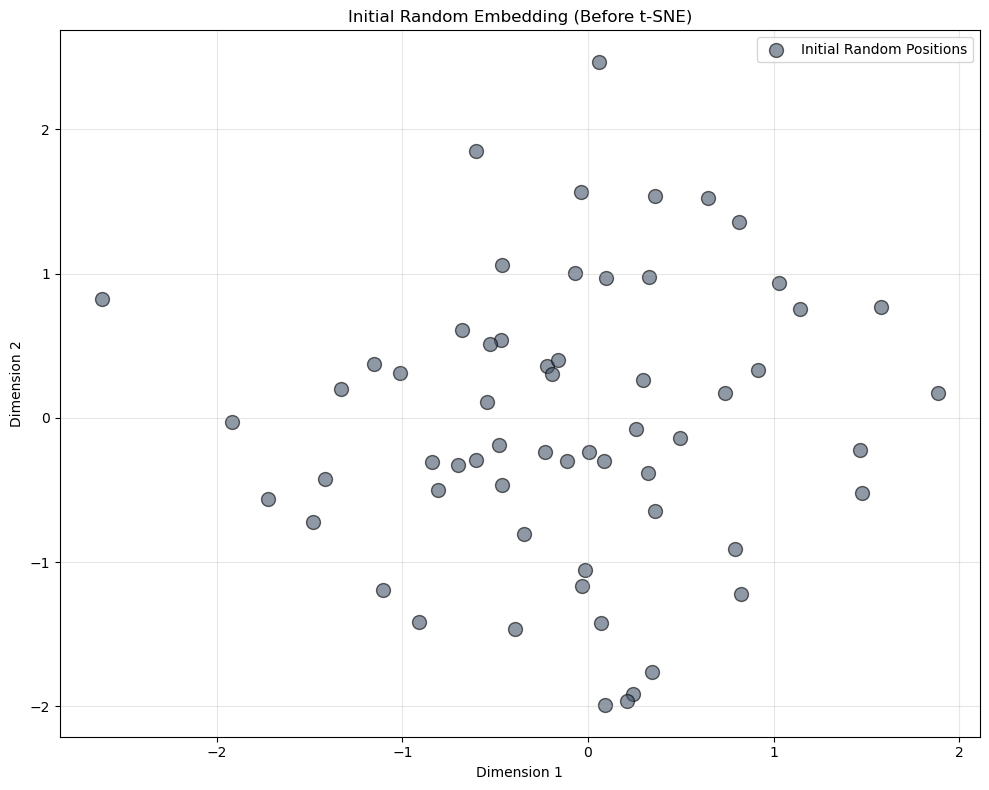

In [5]:
# Initial random low-dimensional embedding before optimization
initial_positions = np.random.randn(df_dist.shape[0], 2)
plt.figure(figsize=(10, 8))
plt.scatter(
    initial_positions[:, 0], initial_positions[:, 1],
    color=colors[-1], s=100, edgecolor='black', alpha=0.6,
    label="Initial Random Positions"
)
plt.title("Initial Random Embedding (Before t-SNE)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

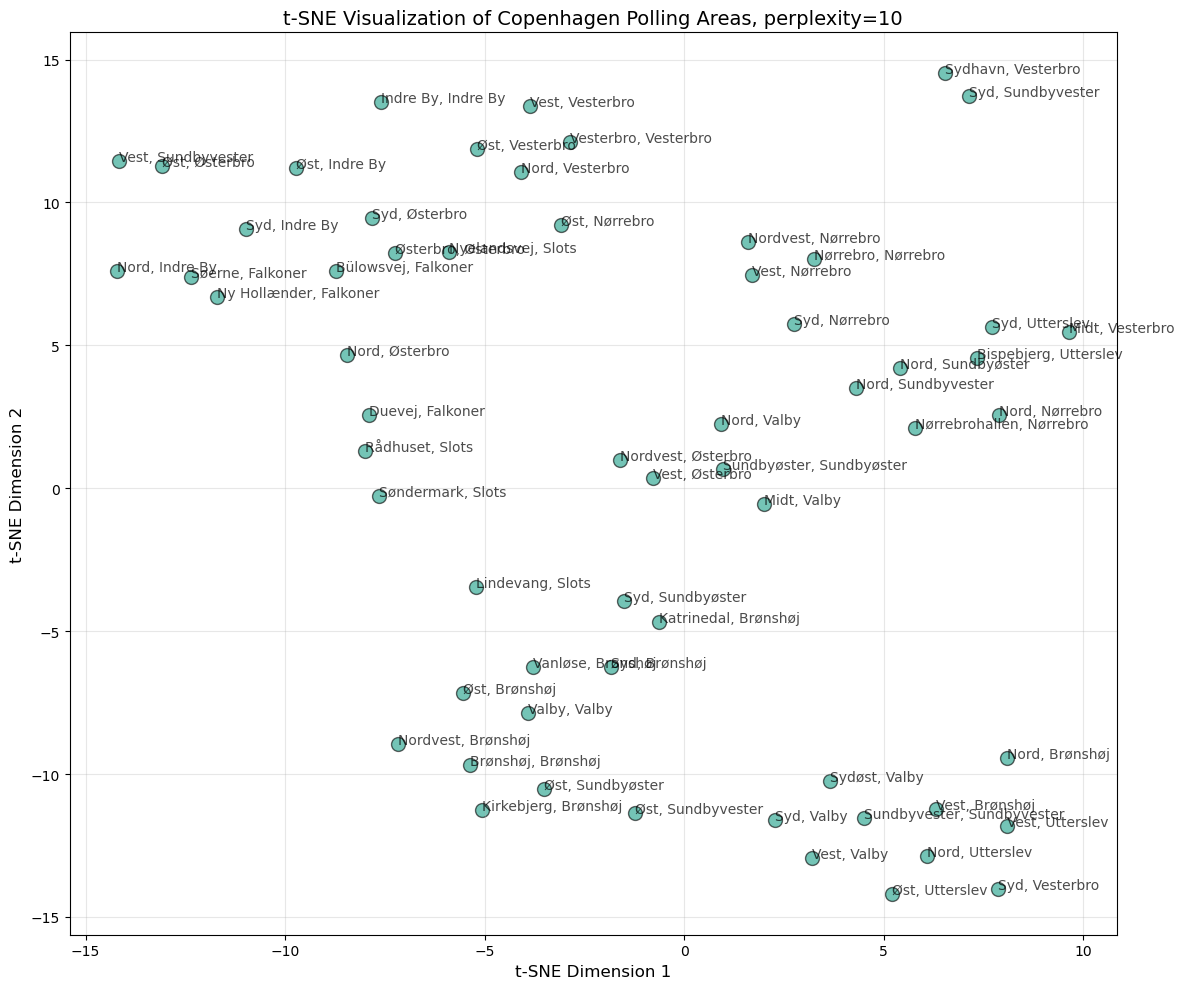

In [6]:
# Apply t-SNE to create a low-dimensional embedding
tsne = TSNE(
    n_components=2,
    perplexity=10, # intepreting perplexity as expected number of neighbours
    random_state=42
)

X_embedded = tsne.fit_transform(df_dist)

# Create df with t-SNE results
df_embedded = pd.DataFrame(
    X_embedded, 
    columns=["t-SNE Dimension 1", "t-SNE Dimension 2"]
)

# Polling area names for labels
df_embedded['Area'] = polling_areas['PollingArea'].values

# Basic plot
plt.figure(figsize=(12, 10))
plt.scatter(
    df_embedded["t-SNE Dimension 1"], 
    df_embedded["t-SNE Dimension 2"],
    s=100, 
    edgecolor='black', 
    alpha=0.6,
    color=colors[1]
)
for idx, row in df_embedded.iterrows():
    plt.annotate(
        row['Area'], 
        (row["t-SNE Dimension 1"], row["t-SNE Dimension 2"]),
        fontsize=10, 
        alpha=0.7
    )
plt.title("t-SNE Visualization of Copenhagen Polling Areas, perplexity=10", fontsize=14)
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Interpretation: Similarity map-ish. If two polling areas are close together in the scatter plot, that means they have similar profiles across all our features.

**Thoughts when we don't set perplexity explicitly:**

We can see that all the polling areas in Frederiksberg are quite close together. 2. Syd (Ørestad) and 9. Sydhavn (Sluseholmen, Teglholmen, Frederiks Brygge) are very close, and these also seem very isolated from the rest. 6. Bispebjerg (Nordvest/Bispebjerg) and 6. Syd (Fuglekvarteret) are very close, and 8. Nord (central Valby) and 4. Sundbyøster (Lergravsparken ish) are very close.

We can also see that the polling areas in kreds 5 (Nørrebro) stay relatively close to each other.

As expected, 7. Nord (Tingbjerg) is very isolated - a possible outlier.

**Thoughts when perplexity is set to 10:**

Clusters are not that obvious.

We see that 2. Syd (Ørestad) and 9. Sydhavn (Sluseholmen, Teglholmen, Frederiks Brygge) are very close, and these also seem very isolated from the rest.

So is a cluster with polling areas that I know have a lot of social housing (almene boliger) and immigrants: 8. Syd (Folehaven), 8. Sydøst (Sjælør Boulevard, but also expensive villa areas in Valby syd), 2. Sundbyvester (parts of Urbanplanen), 9. Syd (Old Sydhavn), 7. Nord (Tingbjerg), 8. Vest (Vigerslev), 7. Vest (parts of Voldparken, Tingbjerg), 6. Nord (Emdrup, also mixed villas and social housing), 6. Øst (also Emdrup, Ryparken), 6.Vest (around Rentemestervej).

Nørrebro polling areas are close together here.

Polling areas in Indre by (central city), Frederiksberg and some of Østerbro are somewhat close together.

There also seems to be a cluster with the hip areas of Vesterbr.

And 7. Katrinedal (central Vanløse) and 4. Syd (south Sundbyøster) are both more suburban polling areas with more villas and some partments, these are also shown as being close together but isolated from the rest.

Setting perplexity lower, e.g. 5, 4 or even 3, makes clusters more obvious:

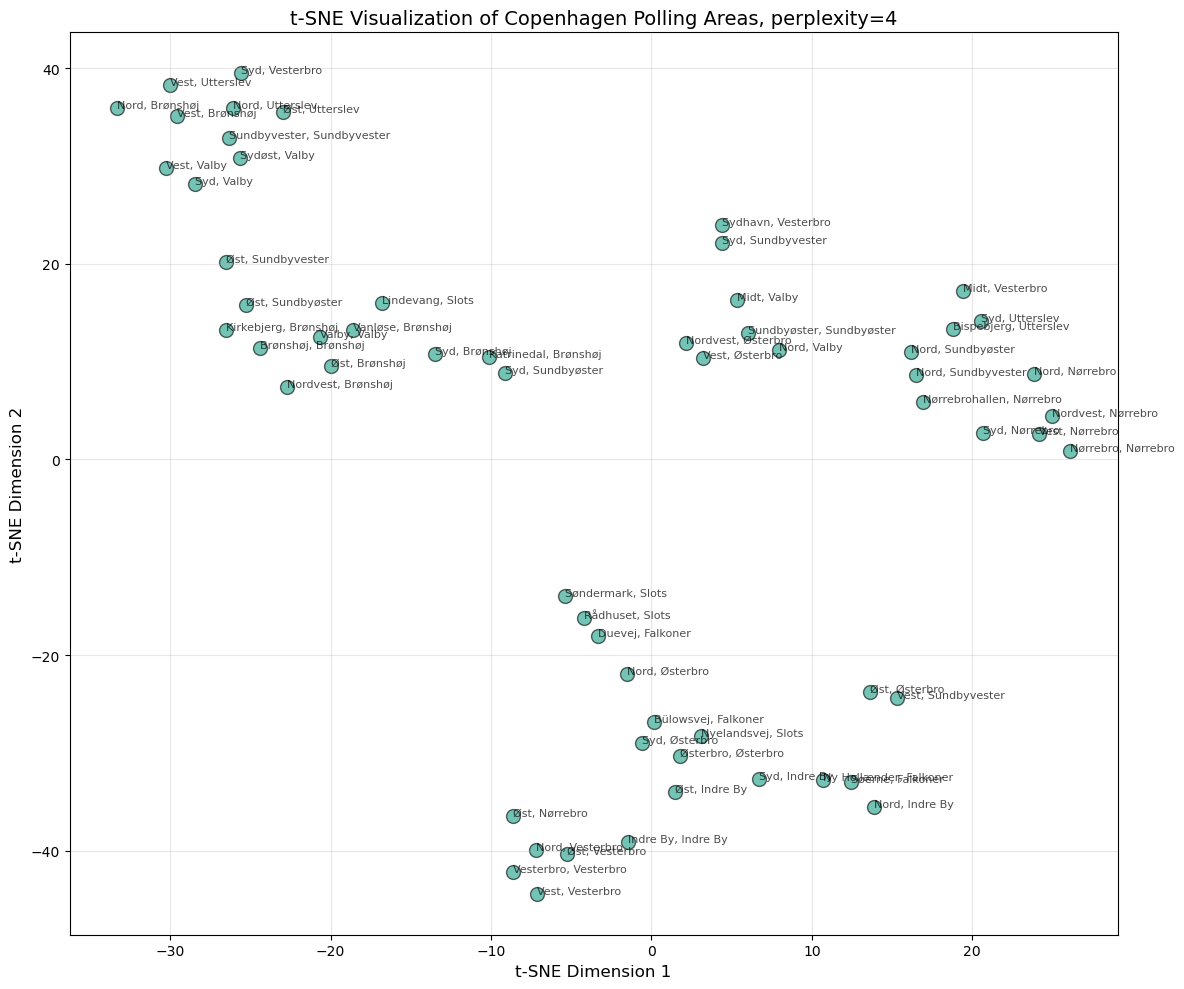

In [7]:
# Apply t-SNE to create a low-dimensional embedding
perplexity = 4
tsne = TSNE(
    n_components=2,
    perplexity=perplexity, # intepreting perplexity as expected number of neighbours
    random_state=42
)

X_embedded = tsne.fit_transform(df_dist)

# Create df with t-SNE results
df_embedded = pd.DataFrame(
    X_embedded, 
    columns=["t-SNE Dimension 1", "t-SNE Dimension 2"]
)

# Polling area names for labels
df_embedded['Area'] = polling_areas['PollingArea'].values

# Basic plot
plt.figure(figsize=(12, 10))
plt.scatter(
    df_embedded["t-SNE Dimension 1"], 
    df_embedded["t-SNE Dimension 2"],
    s=100, 
    edgecolor='black', 
    alpha=0.6,
    color=colors[1]
)
for idx, row in df_embedded.iterrows():
    plt.annotate(
        row['Area'], 
        (row["t-SNE Dimension 1"], row["t-SNE Dimension 2"]),
        fontsize=8, 
        alpha=0.7
    )
plt.title(f"t-SNE Visualization of Copenhagen Polling Areas, perplexity={perplexity}", fontsize=14)
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

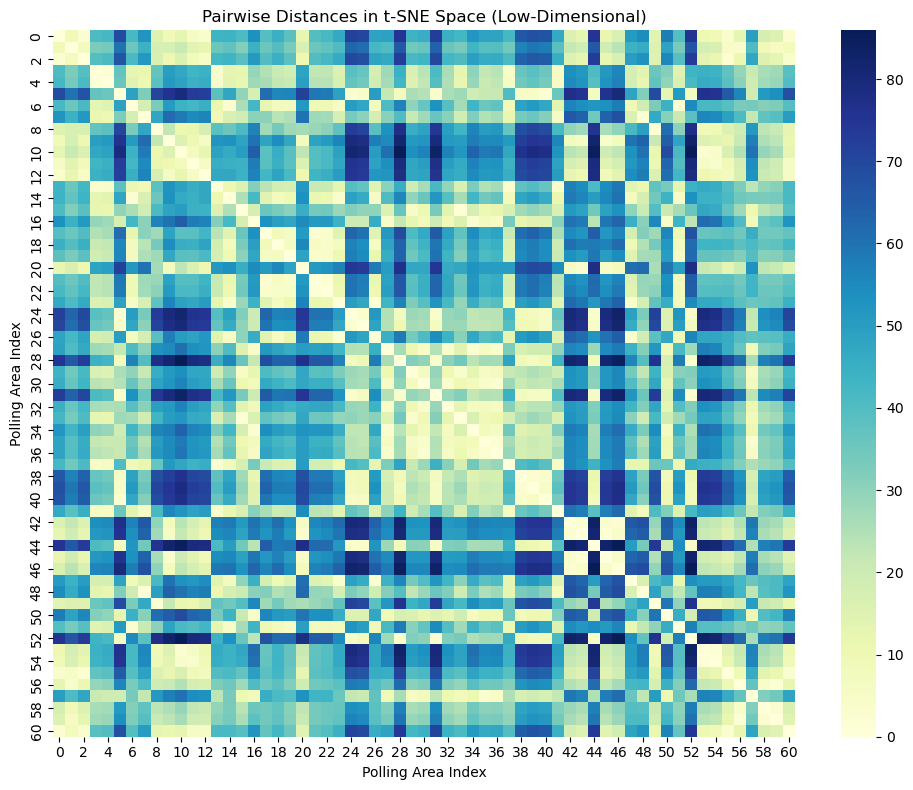

In [8]:
# Calculate pairwise distances in the t-SNE space
pairwise_dist_low_dim = pairwise_distances(X_embedded, metric="euclidean")

# Plot pairwise distances in low-dimensional space
plt.figure(figsize=(10, 8))
sns.heatmap(pairwise_dist_low_dim, cmap="YlGnBu", annot=False, cbar=True)
plt.title("Pairwise Distances in t-SNE Space (Low-Dimensional)")
plt.xlabel("Polling Area Index")
plt.ylabel("Polling Area Index")
plt.tight_layout()
plt.show()

## PCA

### Choose number of components

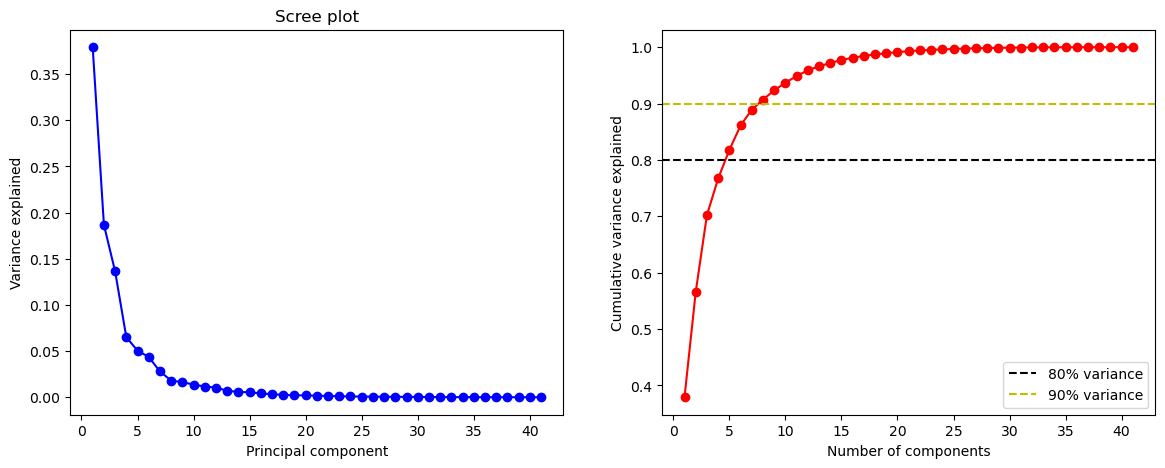

In [9]:
pca = PCA()
pca_result = pca.fit_transform(df_standardised)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(range(1, len(explained_variance)+1), explained_variance, 'bo-')
ax1.set_xlabel('Principal component')
ax1.set_ylabel('Variance explained')
ax1.set_title('Scree plot')

ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'ro-')
ax2.axhline(y=0.8, color='k', linestyle='--', label='80% variance')
ax2.axhline(y=0.9, color='y', linestyle='--', label='90% variance')
ax2.set_xlabel('Number of components')
ax2.set_ylabel('Cumulative variance explained')
ax2.legend()
filename = 'pca_variance'
plt.savefig(f"{OUTPUT_PATH_PNG}{filename}.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{OUTPUT_PATH_PGF}{filename}.pgf")
plt.savefig(f"{OUTPUT_PATH_PDF}{filename}.pdf")

The plots show that the first 5 principal components just over 80 % of the variance. And in the scree plot, the 'elbow point' is also somewhere between the 4th-7th principal component. This tells us that we can retain most information with just 4-7 features.

### Interpret principal components

In [10]:
# Find out which original features contribute most to each PC)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pca.components_))],
    index=df_num.columns
)

# Look at top contributors to first few PCs
print("Top 5 features for PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))
print("\nBottom 5 features for PC1:")
print(loadings['PC1'].sort_values().head(5))
print('\n'+"="*40+'\n')

print("\nTop 5 features for PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))
print("\nBottom 5 features for PC2:")
print(loadings['PC2'].sort_values().head(5))
print('\n'+"="*40+'\n')

print("\nTop 5 features for PC3:")
print(loadings['PC3'].abs().sort_values(ascending=False).head(5))
print("\nBottom 5 features for PC3:")
print(loadings['PC3'].sort_values().head(5))
print('\n'+"="*40+'\n')

print("\nTop 5 features for PC4:")
print(loadings['PC4'].abs().sort_values(ascending=False).head(5))
print("\nBottom 5 features for PC4:")
print(loadings['PC4'].sort_values().head(5))
print('\n'+"="*40+'\n')

print("\nTop 5 features for PC5:")
print(loadings['PC5'].abs().sort_values(ascending=False).head(5))
print("\nBottom 5 features for PC5:")
print(loadings['PC5'].sort_values().head(5))
print('\n'+"="*40+'\n')

Top 5 features for PC1:
Education_30-70+ years_Long higher education          0.237440
Immigrants_Western                                    0.234854
Education_30-70+ years_Primary and lower secondary    0.230970
Immigrants_Global South                               0.229258
Housing tenure_People_Almen                           0.227645
Name: PC1, dtype: float64

Bottom 5 features for PC1:
Education_30-70+ years_Primary and lower secondary   -0.230970
Immigrants_Global South                              -0.229258
Housing tenure_People_Almen                          -0.227645
Education_18-29 years_Primary and lower secondary    -0.226042
Benefit type_Foertidspension                         -0.217177
Name: PC1, dtype: float64



Top 5 features for PC2:
Car_Households with no car                     0.335962
Education_18-29 years_Long higher education    0.295140
Housing tenure_People_Ejer                     0.290052
Housing type_People_Detached house             0.287211
Housing type_Pe

**The PC1 axis** is mostly described by education level, western vs global south, social housing and disability pension - I would call this the main social and western/non-western axis.

**The PC2 axis** is mostly described by owning a car or not, home ownership, detached houses vs apartments, but also somewhat by children and education level (vocational training) - I would call this an urban/suburban axis.

**The PC3 axis** is mostly described by new/old housing, older people, not receiving benefits, Danish citizenship, Other Europe citizenship, to some degree sex - I would say that new neighbourhoods like Ørestad and Teglholmen, Sluseholmen, Frederiks Brygge could probably score high on PC3 (young, lots of internationals, new housing), while Frederiksberg might score low (older females, old housing, Danish).

**The PC4 axis** is mostly described by different things - mostly Eastern European immigration, vocational education level among young people, and Global South citizenship. But also Danish citizenship, young people, housing built in 1960-2009, children, apartments, and entrepreneurs...

**The PC5 axis** is mostly described by sex, age (working age and elderly), housing built in 1960-2009, crime, housing built before 1960...

In [11]:
# Get PC scores
pca_scores = pd.DataFrame(
    pca_result[:, :7],
    columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7'],
    index=df_num.index
)
pca_scores['Area'] = polling_areas['PollingArea'].values

print("=== PC1 - socioeconomy and western/non-western axis ===")
print("\nHigh PC1:")
print(pca_scores.nlargest(5, 'PC1')[['Area', 'PC1']])
print("\nLow PC1:")
print(pca_scores.nsmallest(5, 'PC1')[['Area', 'PC1']])

print("\n=== PC2 - urban/suburban axis, maybe family/single axis ===")
print("High PC2:")
print(pca_scores.nlargest(5, 'PC2')[['Area', 'PC2']])
print("\nLow PC2:")
print(pca_scores.nsmallest(5, 'PC2')[['Area', 'PC2']])

print("\n=== PC3 - newer neighbourhoods vs established neighbourhoods ===")
print("\nHigh PC3:")
print(pca_scores.nlargest(5, 'PC3')[['Area', 'PC3']])
print("\nLow PC3:")
print(pca_scores.nsmallest(5, 'PC3')[['Area', 'PC3']])

print("\n=== PC4 - semi-old/older housing, young vocational workers, Eastern Europe ===")
print("\nHigh PC4:")
print(pca_scores.nlargest(5, 'PC4')[['Area', 'PC4']])
print("\nLow PC4:")
print(pca_scores.nsmallest(5, 'PC4')[['Area', 'PC4']])

print("\n=== PC5 - age, entrepreneurs, sex ===")
print("\nHigh PC5:")
print(pca_scores.nlargest(5, 'PC5')[['Area', 'PC5']])
print("\nLow PC5:")
print(pca_scores.nsmallest(5, 'PC5')[['Area', 'PC5']])

=== PC1 - socioeconomy and western/non-western axis ===

High PC1:
                      Area       PC1
10          Nord, Indre By  7.783136
12           Øst, Indre By  6.051130
49           Øst, Østerbro  5.944645
54  Ny Hollænder, Falkoner  5.838969
53        Søerne, Falkoner  5.477308

Low PC1:
               Area        PC1
28   Nord, Brønshøj -13.415163
31   Vest, Brønshøj  -6.490957
52  Vest, Utterslev  -6.246291
44   Syd, Vesterbro  -6.151926
39      Vest, Valby  -6.010397

=== PC2 - urban/suburban axis, maybe family/single axis ===
High PC2:
                     Area       PC2
18         Nord, Nørrebro  5.218053
26         Syd, Utterslev  5.093600
47        Midt, Vesterbro  4.526830
23  Bispebjerg, Utterslev  4.341885
22     Nordvest, Nørrebro  4.334621

Low PC2:
                    Area       PC2
34  Kirkebjerg, Brønshøj -6.599354
32    Nordvest, Brønshøj -6.560182
27    Brønshøj, Brønshøj -5.660182
16      Øst, Sundbyøster -4.910036
50     Øst, Sundbyvester -3.936848

=== PC3

On the main social and western/Global South axis, Nord, Indre By (Kartoffelrækkerne, Østervold, Ambassadekvarteret), scores the highest and Nord, Brønshøj (Tingbjerg) scores the lowest.

On what I called the urban/suburban or single/family axes, Nord, Nørrebro scores the highest, closely followed by nearby Syd, Utterslev (Fuglekvarteret). Kirkebjerg, Brønshøj and neighbouring Nordvest, Brønshøj (south Husum) score the lowest.

From then on, interpretation gets a lot harder.

I was right that Sydhavn, Vesterbro (Teglholmen, Sluseholmen, Frederiks Brygge) and Syd, Sundbyvester (Ørestad) would score high on PC3.Øst, Sundbyvester scores moderately high - it contains some new housing around ITU and along the metro line, but otherwise parts of Urbanplanen (social housing) and lots of villas, while  Midt, Valby also moderately high, albeit lower - part of that areas is Grønttorvet and Valby Maskinfabrik, a new housing project. However, the fact that Nord, Brønshøj (Tingbjerg) is in the top 5 and Nordhavn (Øst, Østerbro) is not, is weird - so maybe this interpretation isn't completely right. Maybe it's more the absence of old housing? (pre-1960). Or maybe not - Nørrebro, Nørrebro (Guldbergsgade, De Gamles By) scores the lowest, followed by Søndermark, Slots (outer Frederiksberg).

PC4 is interesting - it has our socioeconomic outlier 'Tingbjerg' scoring lowest, and then two central Frederiksberg areas. Weird. On PC5, some Fredriksberg areas scores highest, and Indre By, Indre By scores lowest.

## Save to CSV

In [12]:
n_components = 5 # chosen number of principal components
pca_reduced = PCA(n_components=n_components)
X_pca = pca_reduced.fit_transform(df_standardised)
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)])
df_pca.to_csv(OUTPUT_PATH, index=False)
df_pca

,PC1,PC2,PC3,PC4,PC5
0,3.817743,1.499508,-0.644057,-0.305497,0.784991
1,2.985994,-1.163607,-0.815882,-0.950642,1.581367
2,5.271926,0.953452,-1.297456,-0.817782,-0.697363
3,0.660759,1.135501,0.341928,0.247614,1.752424
4,0.471566,0.177032,-0.013273,0.330951,1.537435
5,-4.232860,-1.787973,-1.178504,-0.636750,0.473085
6,-2.363526,2.303398,-0.644722,-0.104709,1.215852
7,-0.713243,-0.769257,9.299185,0.391138,1.051305
8,5.365213,-2.157715,1.235296,-1.377978,-0.966950
9,3.010904,3.377263,2.699947,-1.644489,-4.738252
